In [1]:
#makemore part4! 继续学习！

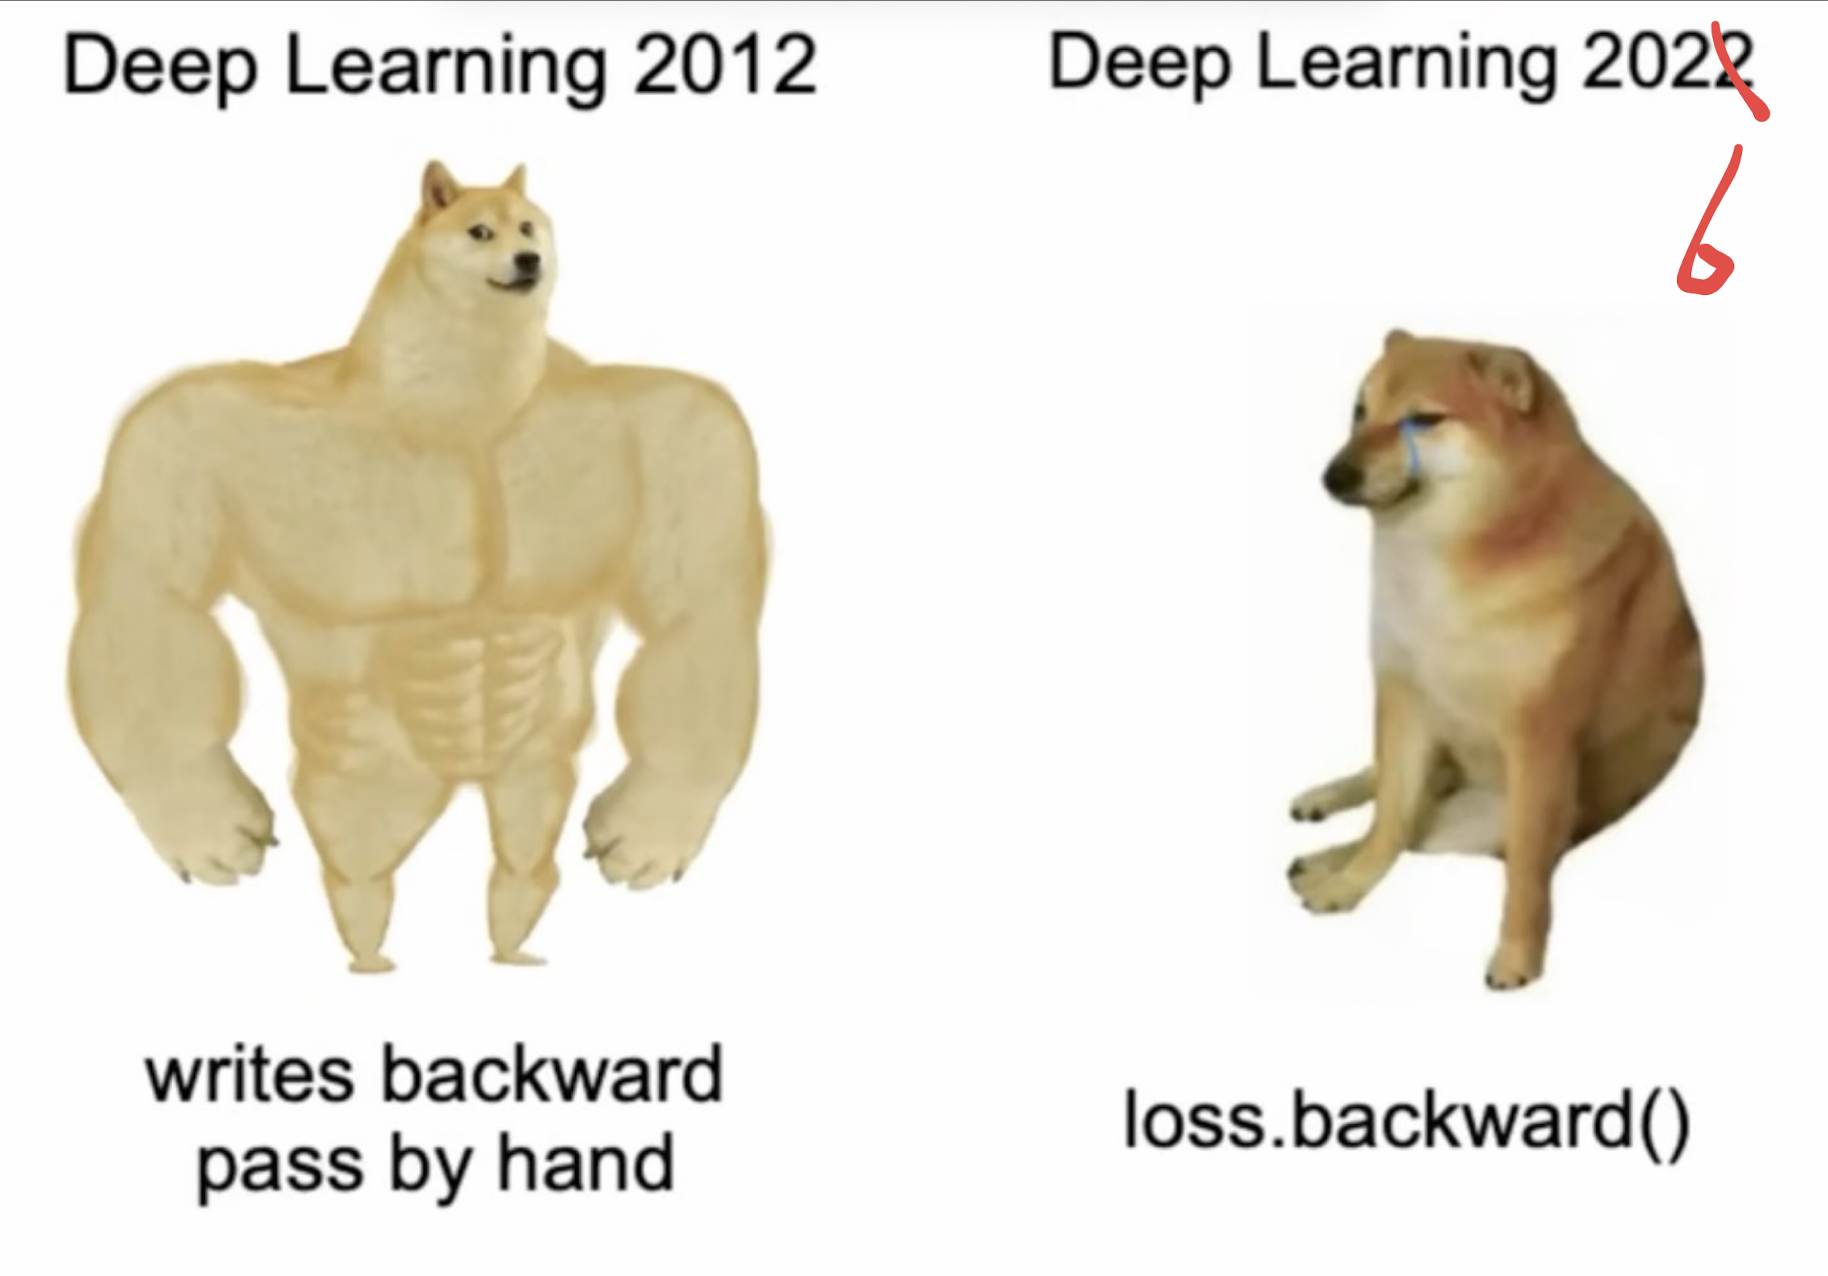

In [2]:
#这一章主要是手写pytorch的反向传播
#之前的反向传播太简单了
#loss.backward()就结束了
#但事实上这是极容易出错的
#所以我们需要重新来实现一下

In [3]:
#前面的初始化代码是一样的

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
words=open("names.txt","r").read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [6]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
vocab_size=len(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
block_size=3

def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2],block_size)#80%~90%
Xte, Yte = build_dataset(words[n2:],block_size)#90~100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
#这是一个辅助比较工具函数
#因为我们需要实现手写的反向传播
#这个函数可以让我们写出来的结果和pytorch的结果相比较
#还能判断误差是多少
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()#比较我们计算的grad和torch生成的grad
  app = torch.allclose(dt, t.grad)#排除浮点数精度问题
  maxdiff = (dt - t.grad).abs().max().item()#看看最大的差值
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [9]:
#一样的初始化，只不过微调了下数值
g = torch.Generator().manual_seed(2147483647)

n_embd=10
n_hidden=64

C = torch.randn((vocab_size, n_embd),          generator=g)         
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)
b1 = torch.randn(n_hidden,                     generator=g)*0.1  
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1  
b2 = torch.randn(vocab_size,                   generator=g)*0.1      

bngain=torch.ones((1,n_hidden))*0.1+1.0
bnbias=torch.zeros((1,n_hidden))*0.1

parameters = [C, W1, b1, W2, b2,bngain,bnbias]
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：4137


In [10]:
#接下来是前向传播的训练部分
#这里andrej把我们之前写的一些东西给拆分成了不同的模块
#因为这里我们要实现backward的手动推导
#所以需要我们小心地去处理计算的部分
#所以这里把一些步骤拆分了出来
batch_size=32
n=batch_size

ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
Xb,Yb=Xtr[ix],Ytr[ix]

emb = C[Xb]
embcat=emb.view(batch_size, block_size*n_embd)
hprebn=embcat@ W1 + b1#h pre bn 在batchnorm之前的h

#bnmeani
bnmeani=hprebn.sum(0,keepdim=True)*(1/n)#这里就是求mean

#hprebn - bnmeani
bndiff=hprebn-bnmeani

#1/bnstdi
bndiff2=bndiff**2
bnvar=1/(n-1)*(bndiff2).sum(0,keepdim=True)
bnvar_inv=(bnvar+1e-5)**-0.5

#(hprebn - bnmeani) / bnstdi
bnraw=bndiff*bnvar_inv

#hpreact
hpreact=bngain*bnraw+bnbias

#h
h=torch.tanh(hpreact)

#logits
logits=h@W2+b2 

#以下是cross_entropy的手动实现
#对logits进行处理，避免出现过大值导致后面的exp出现NaN
logit_maxes=logits.max(1,keepdim=True).values
norm_logits=logits-logit_maxes

#softmax
counts=norm_logits.exp()
counts_sum=counts.sum(1,keepdim=True)
counts_sum_inv=counts_sum**-1
probs=counts*counts_sum_inv

#最大负对数似然
logprobs=probs.log()
loss=-logprobs[range(n),Yb].mean()

#清空梯度
for p in parameters:
    p.grad=None

#保留梯度，可以查看每一步反向传播的具体数值
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
          embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3482, grad_fn=<NegBackward0>)

In [11]:
#接下来的部分我们就是手动实现上面的那一长串的运算过程
#而且反向传播是反过来一级一级去算
#所以我们应当反过来，从后往前一步步求grad

In [12]:
#第一个是logprobs
#求grad就是反过来去看运算过程

In [13]:
logprobs.shape,logprobs[range(n),Yb].shape

(torch.Size([32, 27]), torch.Size([32]))

In [14]:
#可以看到logprobs的shape是batch_size*vocab_size
#下一步是求了每一行的所对应的Yb的对应元素，然后取平均
#也就是说：这一步最后就是32个元素取平均
#那对于这一步，也就是-(++++)/32
#那对于这32个的每一个，grad都是-1/batch_size
#然后对于除了这32个以外的其他元素，grad显然都是0

In [15]:
dlogprobs=torch.zeros_like(logprobs)#这里意思是生成和logprobs形状一样的0张量
dlogprobs[range(n),Yb]=-1.0/n

In [16]:
cmp("logprobs",dlogprobs,logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


In [17]:
#结果正确，logprobs的反向传播函数正确

In [18]:
#probs
#probs->logprobs就是一步log，很简单

In [19]:
dprobs=(1/probs)*dlogprobs
#这里已经不是单层了，所以要乘上下一层的d

In [20]:
cmp("probs",dprobs,probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


In [21]:
#probs正确

In [22]:
#counts_sum_inv

In [23]:
#这个是logits到probs的归一化过程
#logits先进行大值处理
#然后exp后归一化
#这个counts_sum_inv其实就是归一化后的分母

In [24]:
counts_sum_inv.shape,counts.shape

(torch.Size([32, 1]), torch.Size([32, 27]))

In [25]:
#所以每一个counts_sum_inv其实都是counts的一行的exp求和

In [26]:
#所以不难发现counts_sum_inv到probs的计算就是：
#a*C=A,b*C=B,c*C=c,......
#那这样的话每一个C的grad其实就是所有求一遍的和
#但是每一个需要和probs的grad乘一下

In [27]:
dcounts_sum_inv=(counts*dprobs).sum(1,keepdim=True)

In [28]:
cmp("counts_sum_inv",dcounts_sum_inv,counts_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


In [29]:
#counts_sum_inv正确

In [30]:
#counts_sum

In [31]:
#这个很简单，就是单纯的-1次方
dcounts_sum=(-1*counts_sum**-2)*dcounts_sum_inv

In [32]:
cmp("counts_sum",dcounts_sum,counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


In [33]:
#counts

In [34]:
#counts在计算中有两条路径
#一个是->counts_sum->counts_sum_inv
#另一个是直接作用到了probs上

In [35]:
counts_sum.shape,counts.shape

(torch.Size([32, 1]), torch.Size([32, 27]))

In [36]:
#第一个就是求和，那对于每一个元素来说就是单纯的+1
#第二个是*counts_sum_inv

In [37]:
dcounts=torch.ones_like(counts)*dcounts_sum+counts_sum_inv*dprobs

In [38]:
cmp("counts",dcounts_sum,counts_sum)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


In [39]:
#norm_logits

In [40]:
#这一步很简单，就是exp
dnorm_logits=norm_logits.exp()*dcounts

In [41]:
cmp("norm_logits",dnorm_logits,norm_logits)

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


In [42]:
#logit_maxes

In [43]:
#这个看似很简单，但实际上设计广播机制
logit_maxes.shape,norm_logits.shape

(torch.Size([32, 1]), torch.Size([32, 27]))

In [44]:
#可以看到logit_maxes被广播了
#所以这一步需要求和
dlogit_maxes=(-dnorm_logits).sum(1,keepdim=True)

In [45]:
cmp("logit_maxes",dlogit_maxes,logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


In [46]:
#logits

In [47]:
#logits和counts一样，具有两条路径
#第一个就是单纯的1
#第二个会作用到max
#这样的话logits里的每一行的最大值对max的偏导就是1

#关于求max，其实torch.max会存储是哪一个
logits.max(1)

torch.return_types.max(
values=tensor([1.0230, 0.8773, 1.2418, 0.6361, 1.7365, 0.9537, 0.8150, 1.4842, 1.0861,
        1.1175, 1.7868, 2.0955, 1.1189, 0.9202, 0.5922, 0.8290, 0.9719, 0.7808,
        1.1189, 0.8777, 0.8088, 1.0604, 1.1189, 1.2769, 1.6185, 1.0034, 1.2943,
        1.0409, 1.0030, 0.7977, 1.1389, 0.9284], grad_fn=<MaxBackward0>),
indices=tensor([ 1,  2, 19, 15, 15, 25, 16,  3, 19,  8, 15,  3, 22, 18,  7,  5,  2,  1,
        22, 19, 15, 19, 22, 22, 23,  5, 22, 20, 24,  8, 24, 13]))

In [48]:
#可以看到后面的indices存储了具体是哪一个
logits.max(1).indices

tensor([ 1,  2, 19, 15, 15, 25, 16,  3, 19,  8, 15,  3, 22, 18,  7,  5,  2,  1,
        22, 19, 15, 19, 22, 22, 23,  5, 22, 20, 24,  8, 24, 13])

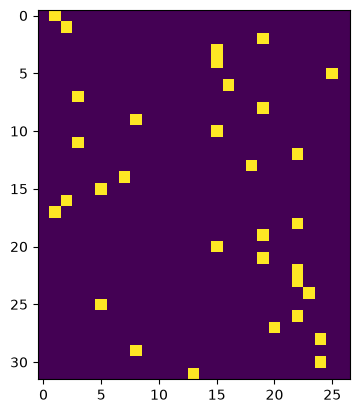

In [49]:
#这样就能显示具体是哪一个
#然后对于这些，偏导应该是1，其余的是0
#所以用one_hot就很不错
plt.imshow(F.one_hot(logits.max(1).indices,num_classes=logits.shape[1]))

In [50]:
dlogits=F.one_hot(logits.max(1).indices,num_classes=logits.shape[1])*dlogit_maxes+dnorm_logits.clone()

In [51]:
cmp("logits",dlogits,logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


In [52]:
#h,W2,b2
logits.shape,h.shape,W2.shape,b2.shape

(torch.Size([32, 27]),
 torch.Size([32, 64]),
 torch.Size([64, 27]),
 torch.Size([27]))

In [53]:
#这是三者的形状
#首先b2应该是很简单的，他会根据广播机制传播到每一个
db2=dlogits.sum(0)

In [54]:
cmp("b2",db2,b2)

b2              | exact: True  | approximate: True  | maxdiff: 0.0


In [55]:
#再来看看剩下的两个
#a12=b11*c12+b12*c22+b13*c32+......
#这个就是h和W2的内部计算逻辑
#所以对于logits中的每一个元素，应该都是很多个数的加和
#那这样就不难了
#比如说对于b11
#他会对a11,a12,a13,......都有贡献
#a11=b11*c11+...
#a12=b11*c12+...
#但是这么看还是好复杂，怎么计算呢？

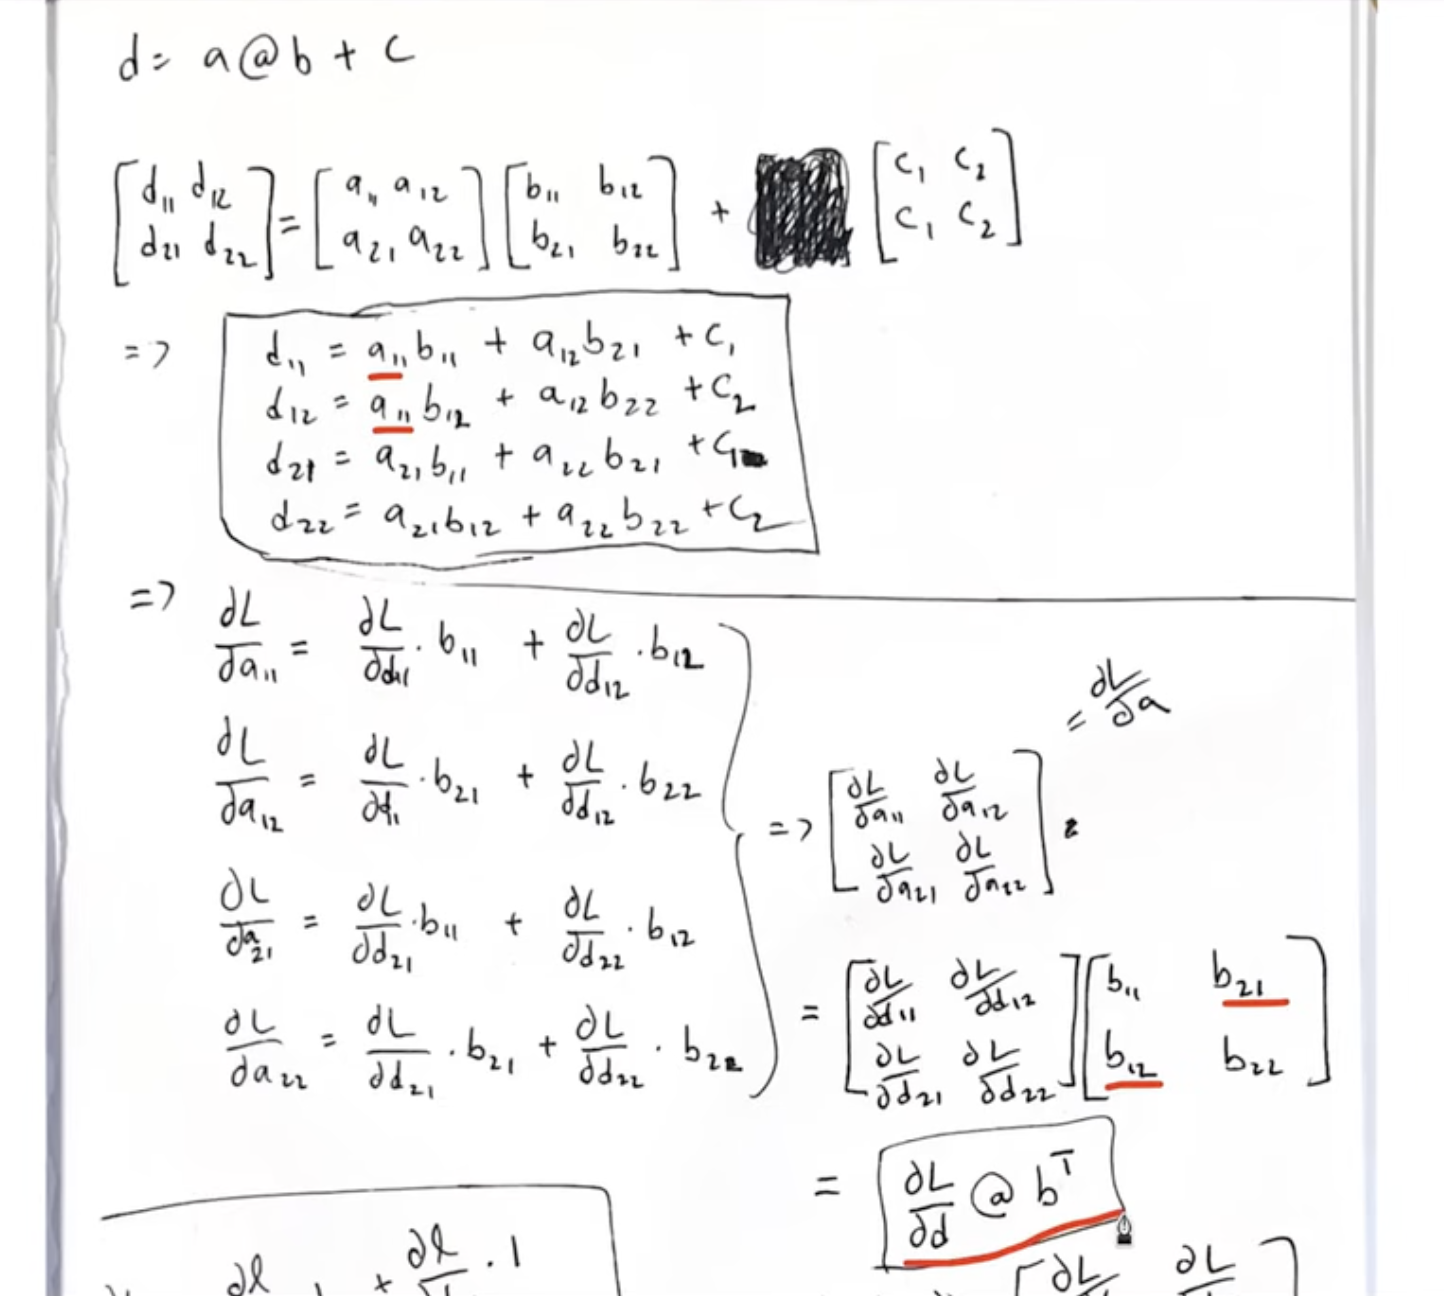

In [56]:
#andrej这里帮我们用纸笔推导了一下
#可以发现：
#其实偏导矩阵，就是logits的偏导矩阵乘另一个矩阵的转置
#还有个很邪修的方法
#比如h的形状是32*64，那想乘出这样的矩阵只能是logits和W2的转置去乘

In [57]:
dh=dlogits@W2.T#这里要用矩阵乘法

In [58]:
dW2=h.T@dlogits

In [59]:
cmp("h",dh,h)
cmp("W2",dW2,W2)

h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0


In [60]:
#hpreact

In [61]:
#这个也很简单，就是tanh的导数
#a=tanh(z)
#da/dz=1-a^2
#这里比较神奇的是求出来的导数是和a有关的
dhpreact=(1.0-h**2)*dh

In [62]:
cmp("hpreact",dhpreact,hpreact)

hpreact         | exact: True  | approximate: True  | maxdiff: 0.0


In [63]:
#bngain，bnraw，bnbias

In [64]:
bngain.shape,bnraw.shape,bnbias.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([1, 64]))

In [65]:
#hpreact=bngain*bnraw+bnbias
#这三个要注意形状！也涉及到了广播机制
dbngain=(bnraw*dhpreact).sum(0,keepdim=True)
dbnraw=dhpreact*bngain
dbnbias=dhpreact.sum(0,keepdim=True).clone()

In [66]:
cmp("bngain",dbngain,bngain)
cmp("bnraw",dbnraw,bnraw)
cmp("bnbias",dbnbias,bnbias)

bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0


In [67]:
#bnvar_inv

In [68]:
bnvar_inv.shape,bndiff.shape,bnraw.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [69]:
#这里显然也要设计广播机制了
dbnvar_inv=(bndiff*dbnraw).sum(0,keepdim=True)

In [70]:
cmp("bnvar_inv",dbnvar_inv,bnvar_inv)

bnvar_inv       | exact: True  | approximate: True  | maxdiff: 0.0


In [71]:
#bnvar

In [72]:
#bnvar_inv=(bnvar+1e-5)**-0.5
#这个自然也和简单，就是个单纯的指数
dbnvar=-0.5*(bnvar+1e-5)**-1.5*dbnvar_inv

In [73]:
cmp("bnvar",dbnvar,bnvar)

bnvar           | exact: True  | approximate: True  | maxdiff: 0.0


In [74]:
#bndiff2

In [75]:
#bnvar=1/(n-1)*(bndiff2).sum(0,keepdim=True)
#这是一个求和之后的乘法，也不难
bnvar.shape,bndiff2.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [76]:
dbndiff2=1/(n-1)*dbnvar*torch.ones_like(bndiff2)

In [77]:
cmp("bndiff2",dbndiff2,bndiff2)

bndiff2         | exact: True  | approximate: True  | maxdiff: 0.0


In [78]:
#bndiff

In [79]:
#bndiff2=bndiff**2
#bnraw=bndiff*bnvar_inv
#两步都比较简单
bndiff2.shape,bndiff.shape,bnvar_inv.shape,bnraw.shape

(torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]))

In [80]:
dbndiff=2*bndiff*dbndiff2+bnvar_inv*dbnraw

In [81]:
cmp("bndiff",dbndiff,bndiff)

bndiff          | exact: True  | approximate: True  | maxdiff: 0.0


In [82]:
#bnmeani

In [83]:
#bndiff=hprebn-bnmeani
bnmeani.shape,bndiff.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [84]:
dbnmeani=-1*dbndiff.sum(0,keepdim=True)

In [85]:
cmp("bnmeani",dbnmeani,bnmeani)

bnmeani         | exact: True  | approximate: True  | maxdiff: 0.0


In [86]:
#hprebn

In [87]:
#bnmeani=hprebn.sum(0,keepdim=True)*(1/n)#这里就是求mean
#bndiff=hprebn-bnmeani 这里也涉及到两步操作
bnmeani.shape,hprebn.shape,bndiff.shape

(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [88]:
#这里就是一步求平均，所以也比较简单
dhprebn=torch.ones_like(hprebn)*dbnmeani*(1/n)+dbndiff

In [89]:
cmp("hprebn",dhprebn,hprebn)

hprebn          | exact: True  | approximate: True  | maxdiff: 0.0


In [90]:
#embcat,W1,b1

In [91]:
#hprebn=embcat@ W1 + b1
#这里跟之前的W2，b2应该是类似的
hprebn.shape,embcat.shape,W1.shape,b1.shape

(torch.Size([32, 64]),
 torch.Size([32, 30]),
 torch.Size([30, 64]),
 torch.Size([64]))

In [92]:
db1=dhprebn.sum(0)
dembcat=dhprebn@W1.T
dW1=embcat.T@dhprebn

In [93]:
cmp("b1",db1,b1)
cmp("embcat",dembcat,embcat)
cmp("W1",dW1,W1)

b1              | exact: True  | approximate: True  | maxdiff: 0.0
embcat          | exact: True  | approximate: True  | maxdiff: 0.0
W1              | exact: True  | approximate: True  | maxdiff: 0.0


In [94]:
#emb

In [95]:
#embcat=emb.view(batch_size, block_size*n_embd)
#这里就是换了下形状，所以对应过来应该是一样的
emb.shape,embcat.shape

(torch.Size([32, 3, 10]), torch.Size([32, 30]))

In [96]:
demb=dembcat.view(emb.shape)

In [97]:
cmp("emb",demb,emb)

emb             | exact: True  | approximate: True  | maxdiff: 0.0


In [98]:
#C

In [99]:
#emb = C[Xb]

In [100]:
C.shape,Xb.shape,emb.shape

(torch.Size([27, 10]), torch.Size([32, 3]), torch.Size([32, 3, 10]))

In [101]:
#这里是把Xb里的30个字符提取出来作为emb
dC=torch.zeros_like(C)
for i in range(Xb.shape[0]):
    for k in range(Xb.shape[1]):
        dC[Xb[i][k]]+=demb[i][k]

In [102]:
cmp("C",dC,C)

C               | exact: True  | approximate: True  | maxdiff: 0.0


In [103]:
#手动反向传播完成！

In [104]:
#下一个练习是整合我们的部分计算
#思考一下：为什么刚刚那么长一串的东西可以整合成一个cross_entropy呢？
#因为计算其实是可以整体来化简的
#如果有些计算我们往往总是放在一起算，那完全可以合在一起求导
#就好比如果出现一个算式是y=2*3*5(x+4)
#没有人会一层一层算，而是直接转化为y=30x+120,求导直接就是30
#cross_entropy也是一样
#我们可以实现比较简洁的偏导

In [105]:
loss_fast=F.cross_entropy(logits,Yb)
print(loss_fast.item(),'diff:',(loss_fast-loss).item())

3.348198175430298 diff: 2.384185791015625e-07


In [106]:
#两者结果是一样的，但是cross_entropy会快很多
#接下来我们就来化简
#化简方式就是直接求其中的某些值

In [107]:
#首先我们来看logits到loss
#logits--softmax-->probs--负对数似然-->loss
logits.shape,probs.shape,loss.shape

(torch.Size([32, 27]), torch.Size([32, 27]), torch.Size([]))

In [108]:
#这里的logits和probs有一个batch的维度，其实就是在横向上取loss
#最后应该先有一个(32,1)的loss
#然后平均得到最后的loss

#接下来的推导先关注于batch为1的loss，也就是logits为(1,27)

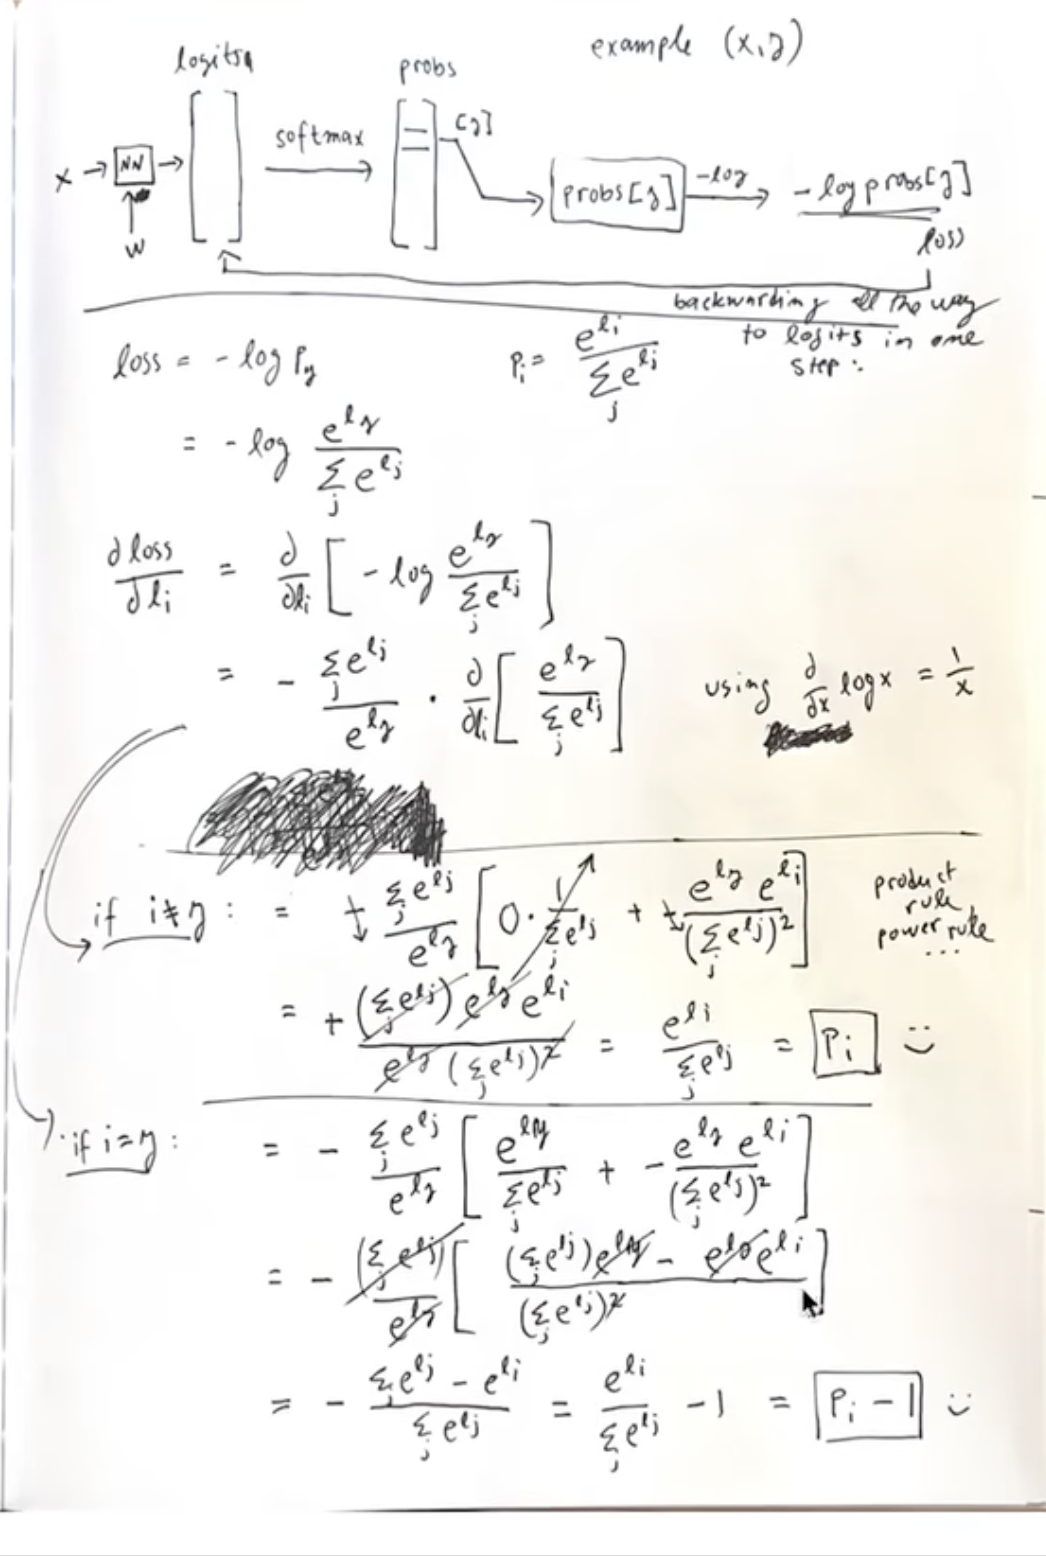

In [109]:
#推导过程在这里，读者可以自己用纸笔算一下

In [110]:
#最后我们得到的结果是：
#loss关于logits[i]的偏导=probs[i]-1(i==y);probs[i](i!=y)
#y是正确答案

In [111]:
dlogits=F.softmax(logits,1)
dlogits[range(n),Yb]-=1
dlogits=(1/n)*dlogits

In [112]:
cmp("logits",dlogits,logits)

logits          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-09


In [113]:
#可以看到虽然不是完美匹配，但是差距非常小，这只是浮点数计算导致的，说明我们的计算其实是对的